# 02. Neural Network classification with Pytorch  

Classification is a problem of predicting whether something is onething or another (there can be multiple things as the options)  

## 1. Make classification data and get it ready

In [112]:
import sklearn
from sklearn.datasets import make_circles

In [113]:
## Make the 1000 samples
n_samples = 1000 

#Create circles 
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42

)



In [114]:
len(X) , len(y)

(1000, 1000)

In [115]:
print(f"First 5 samples of X : {X[:5]}")
print(f"First 5 samples of y : {y[:5]}")

First 5 samples of X : [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y : [1 1 1 1 0]


In [116]:
# make the dataframe of circle data 
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:,1],
                        "labels": y
                        })

In [117]:
circles.head(10)

,X1,X2,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


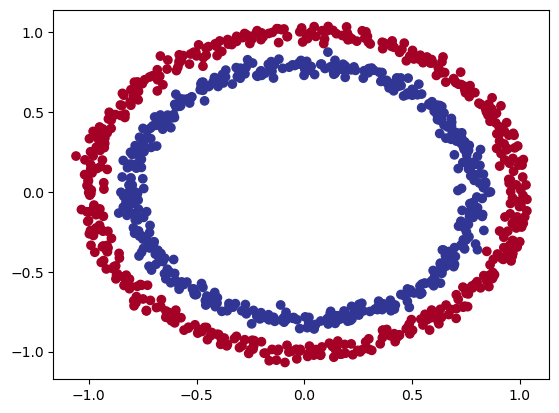

In [118]:
# Visualize 
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu
            )

NOTE: the data we are working with is often refered to as a toy dataset, a dataset that is small enough to experiment but still sizable enough to practice the fundamentals

### 1.1 Check input and output shapes

In [119]:
X.shape , y.shape

((1000, 2), (1000,))

In [120]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [121]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values of one sample of X {X_sample} and the same for y : {y_sample}")
print(f"Shapes for oe sample of X: {X_sample.shape} and same for y: {y_sample.shape}")

Values of one sample of X [0.75424625 0.23148074] and the same for y : 1
Shapes for oe sample of X: (2,) and same for y: ()


### 1.2 Turn the data into the tensors and create the train and test splits

In [122]:
# Turn the data into the tensors
import torch
torch.__version__

'2.5.1'

In [123]:
type(X),X.dtype

(numpy.ndarray, dtype('float64'))

In [124]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)


In [125]:
X[0],y[0]

(tensor([0.7542, 0.2315]), tensor(1.))

In [126]:
type(X),X.dtype,y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [127]:
torch.manual_seed(42)

In [128]:
# Split data into training and test set
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
                                                X,
                                                y,
                                                test_size=0.2, # 20 % of the data will test
                                                random_state=42
                                                )

In [129]:
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Lets build the model to classify the blue and red dots.  

To do , we want to 

1. Setup the device agnostic code   
2. construct a model (by subclassing `nn.module`)
3. define the loss function and optimizer 
4. create the train and test loop  

In [130]:
# Import pytorch and nn 

import torch 
from torch import nn

# device agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"

device 

'cuda'

In [131]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we have setup the device agnostic code, lets create the model  

1. Subclass `nn.Module` (almost all model in pytorch subclass `nn.Module`)
2. Create the `nn.Linear()` layers that are capable of handling the shapes of our data 
3. Defines a `forward()` method that outlines the forward pass 
4. Instatiate an instance of our model class and send it to the target `device` 

In [132]:
X_train.shape,X_train

(torch.Size([800, 2]),
 tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         ...,
         [ 0.0157, -1.0300],
         [ 1.0110,  0.1680],
         [ 0.5578, -0.5709]]))

In [133]:
# 1. Construct the model that subclasses nn.Module

class CirclemodelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create nn.Linear layers capable of handling the shapes of our data
        self.layer_1 = nn.Linear(in_features=2,
                                 out_features=5) # takes 2 features and upscales 5 features
        self.layer_2 = nn.Linear(in_features=5,
                                out_features=1) # takes 5 features from previous layer and outputs a single feature( same as the y)
     #3. Define the forward method   
    def forward(self,X):
        return self.layer_2(self.layer_1(X))   # X -> layer_1 -> layer_2 -> Output
    
 #4. Instatiate an instance of our model class and send it to the target device   

model_0 = CirclemodelV0().to(device)
model_0




CirclemodelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [134]:
device

'cuda'

In [135]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [136]:
# Lets replicate the model above using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)


In [137]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [138]:
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [139]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [140]:
# Make some predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup the loss function and optimizer

Which loss function or optimizer should you use ?  

Again.. this is problem specific  

For example for regression you might use MAE or MSE

For classifcation you might use binary cross entropy or categorical cross entropy.  

As a reminder , the loss function measures how wrong your models predictions are.  

And for optimizers, two most common and usefull are SGD and Adam, however Pytorch has many built-in options


In [141]:
## Setup loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(
                        params=model_0.parameters(),
                        lr=0.1
)

In [142]:
# Function to calculate classification accuracy (percentage of correct predictions)
def accuracy_fn(y_true, y_pred):
    
    # Compare predicted labels with true labels and count how many are correct
    correct = torch.eq(y_true, y_pred).sum().item()
    
    # Divide correct predictions by total predictions and convert to percentage
    acc = (correct / len(y_pred)) * 100
    
    # Return the accuracy value
    return acc

## 3. Training the model  

1. Forward pass  
2. calculate the loss  
3. optimizer zero grad  
4. Loss backward (backpropagation)  
5. Optimizer step (gradient descent)  

### Going from the raw logits -> prediction probabilities -> prediction labels  

Our models outputs are going to be raw **logits**  

We can convert these logits into prediction probabilities by passing them to some kind of activation function (eg sigmoid for binary classification and softmax for multiclass classification).  

Then we can convert our model prediction probabilities to prediction labels by either rounding them or taking `argmax()`  

In [143]:
# View the first 5 output of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [144]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [145]:
# Use the sigmoid activation on our model logits to turn them into prediction probabailities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

For our prediction probability values, we need to perform a range-style rounding on them:  

* `y_pred_probs` >= 0.5, `y=1` (class 1)
* `y_pred_probs` < 0.5, `y=0` (class 0)



In [146]:
# find the predicted labels
y_preds = torch.round(y_pred_probs)



### 3.2 Building a training and testing loop


In [147]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 200

#put the data into target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


#Building training and evaluation loop
for epoch in range(epochs):

    #train
    model_0.train()

    #forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

    # calculate loss/accuracy
    """loss = loss_fn(
                    torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities as input
                    y_train
    )"""
    loss = loss_fn(
                    y_logits, # nn.BCEWithLogitsLoss expects raw logits as input
                    y_train)
    
    acc = accuracy_fn(
                        y_true=y_train,
                        y_pred=y_pred)
    
    # Optimizer zero grad

    optimizer.zero_grad()

    # loss backward

    loss.backward()

    #optimizer step (gradient descent)
    optimizer.step()

    ### testing 
    model_0.eval()
    with torch.inference_mode():
        # frwd pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))


        # calculate test loss/acc
        test_loss = loss_fn(
                            test_logits,
                            y_test
        )

        test_acc = accuracy_fn(
                            y_true=y_test,
                            y_pred= test_pred
        )

    # print out whats happening 

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | loss: {loss:.5f}, Acc: {acc:.2f}%  | Test loss {test_loss:.5f}, Test acc: {test_acc:.2f}%")





Epoch: 0 | loss: 0.69796, Acc: 51.88%  | Test loss 0.69440, Test acc: 58.00%
Epoch: 10 | loss: 0.69590, Acc: 51.25%  | Test loss 0.69305, Test acc: 53.00%
Epoch: 20 | loss: 0.69490, Acc: 51.62%  | Test loss 0.69254, Test acc: 49.50%
Epoch: 30 | loss: 0.69435, Acc: 51.12%  | Test loss 0.69236, Test acc: 49.50%
Epoch: 40 | loss: 0.69401, Acc: 50.88%  | Test loss 0.69232, Test acc: 51.00%
Epoch: 50 | loss: 0.69378, Acc: 50.25%  | Test loss 0.69234, Test acc: 50.00%
Epoch: 60 | loss: 0.69362, Acc: 50.00%  | Test loss 0.69239, Test acc: 51.50%
Epoch: 70 | loss: 0.69351, Acc: 50.25%  | Test loss 0.69246, Test acc: 51.00%
Epoch: 80 | loss: 0.69342, Acc: 49.88%  | Test loss 0.69254, Test acc: 50.00%
Epoch: 90 | loss: 0.69336, Acc: 49.88%  | Test loss 0.69262, Test acc: 53.00%
Epoch: 100 | loss: 0.69331, Acc: 49.25%  | Test loss 0.69271, Test acc: 53.00%
Epoch: 110 | loss: 0.69327, Acc: 49.75%  | Test loss 0.69279, Test acc: 54.00%
Epoch: 120 | loss: 0.69324, Acc: 50.25%  | Test loss 0.69286, T

## 4. make predictions and evaluate the model

from the metrices it look like our model is not learning anything..

So to inspect it lets make some predictions and make them visual !!

in other words, "Visualize Visualize Vizualize"

In [148]:
import requests
from pathlib import Path

# Download the helper functions from Learn pytorch repo.

if Path("helper_function.py").is_file():
    print("helper_functions.py is exists")

else:
    print(" Download the helper_function.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py","wb") as f:
        f.write(request.content)


 Download the helper_function.py


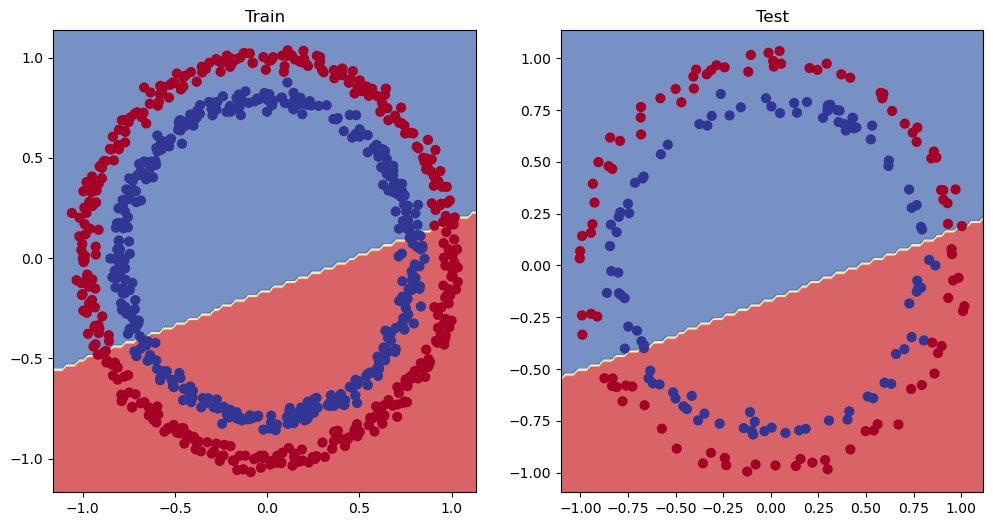

In [149]:
from helper_functions import plot_predictions, plot_decision_boundary
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Improving a model (From a model perspective)  

* Add more layers - give the model more chance to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units
* Fit for longer
* Change the activation function
* Change the learning rate
* Change the loss function

In [150]:
class CirclemodelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=10)
        self.layer2 = nn.Linear(in_features=10, out_features=10)
        self.layer3 = nn.Linear(in_features=10, out_features=1)

    def forward(self,x):
        #z = self.layer1(x)
        #z = self.layer2(z)
        #z = self.layer3(z)
        return self.layer3(self.layer2(self.layer1(x)))
    
model_1 = CirclemodelV1().to(device)
model_1

CirclemodelV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [151]:
model_1.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, 

In [152]:
# Create the loss function
loss_fn = nn.BCEWithLogitsLoss()

# create the optimizer
optimizer = torch.optim.SGD(
                            params=model_1.parameters(),
                            lr=0.1)



In [153]:
# Write the training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#train for longer epochs
epochs = 1000 

#Put data on the target device 

X_train , y_train = X_train.to(device), y_train.to(device)
X_test , y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

    model_1.train()

    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> pred probabilities -> prediction labels

    #loss /accuracy 

    loss = loss_fn(y_logits,y_train)

    acc = accuracy_fn(y_true=y_train,y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ## test 

    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,y_test)

        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} Acc: | {acc:.2f}% | Testloss: {test_loss:.5f} | Test acc: {test_acc:.2f}%  ")


Epoch: 0 | Loss: 0.69396 Acc: | 50.88% | Testloss: 0.69261 | Test acc: 51.00%  
Epoch: 100 | Loss: 0.69305 Acc: | 50.38% | Testloss: 0.69379 | Test acc: 48.00%  
Epoch: 200 | Loss: 0.69299 Acc: | 51.12% | Testloss: 0.69437 | Test acc: 46.00%  
Epoch: 300 | Loss: 0.69298 Acc: | 51.62% | Testloss: 0.69458 | Test acc: 45.00%  
Epoch: 400 | Loss: 0.69298 Acc: | 51.12% | Testloss: 0.69465 | Test acc: 46.00%  
Epoch: 500 | Loss: 0.69298 Acc: | 51.00% | Testloss: 0.69467 | Test acc: 46.00%  
Epoch: 600 | Loss: 0.69298 Acc: | 51.00% | Testloss: 0.69468 | Test acc: 46.00%  
Epoch: 700 | Loss: 0.69298 Acc: | 51.00% | Testloss: 0.69468 | Test acc: 46.00%  
Epoch: 800 | Loss: 0.69298 Acc: | 51.00% | Testloss: 0.69468 | Test acc: 46.00%  
Epoch: 900 | Loss: 0.69298 Acc: | 51.00% | Testloss: 0.69468 | Test acc: 46.00%  


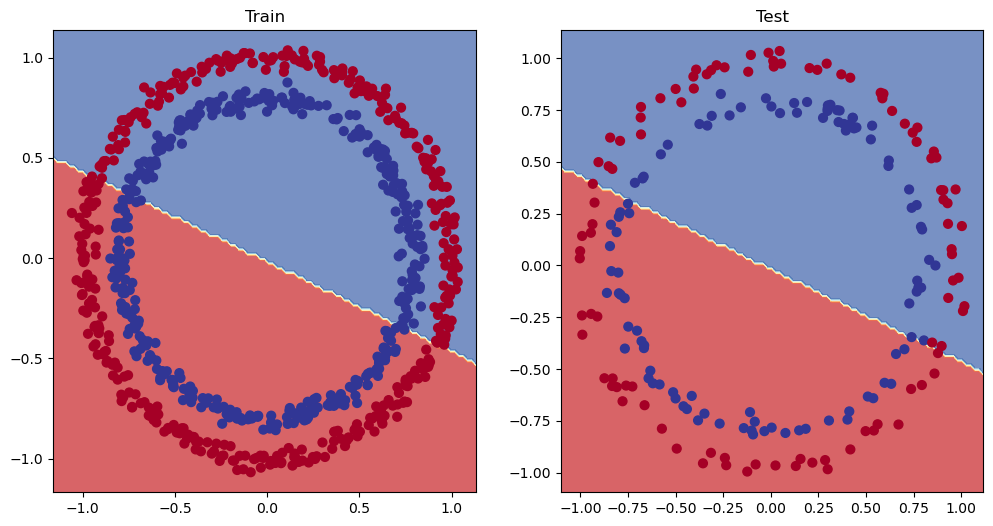

In [154]:
# plot the decision boundary 

from helper_functions import plot_predictions, plot_decision_boundary
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)


### 5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot to a large problem is to test out a similar problem

In [155]:
# Create some data (same as notebook 01)

weight = 0.7 
bias = 0.3 

start = 0 
end = 1
step = 0.01

X_regression = torch.arange(start ,end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias


print(len(X_regression))
X_regression[:5] , y_regression[:5]





100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [156]:
# create the train and test split

train_split = int(0.8 * len(X_regression))

X_train_regression , y_train_regression = X_regression[:train_split],y_regression[:train_split]
X_test_regression , y_test_regression = X_regression[train_split:],y_regression[train_split:]

len(X_train_regression),len(X_test_regression),len(y_train_regression),len(y_test_regression)

(80, 20, 80, 20)

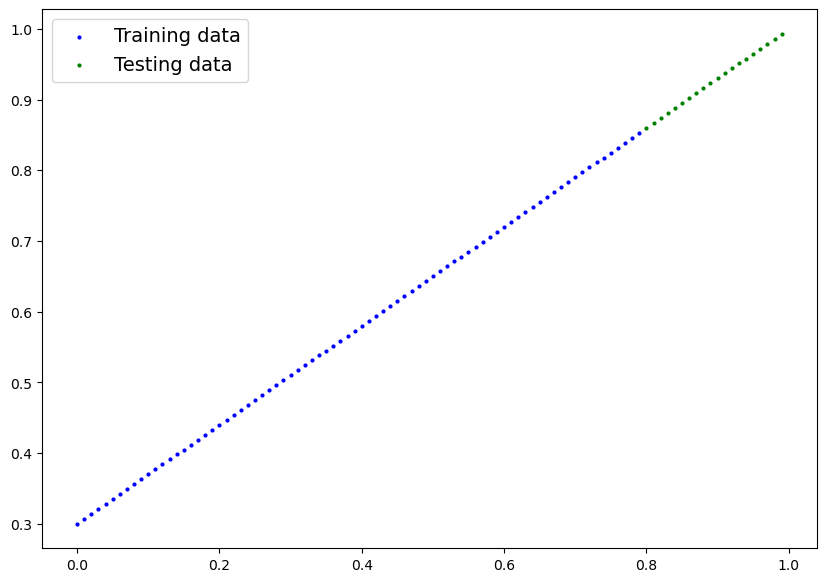

In [157]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression)


In [158]:
model_1

CirclemodelV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

### 5.2 Adjusting `model_` to fit a straight line 

In [159]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [160]:
# Loss and optimizer 

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(),
                            lr = 0.1)

In [161]:
# Train the model

torch.manual_seed(42)
torch.cuda.manual_seed(42)


epochs = 1000

X_train_regression , y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression , y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):

    y_pred = model_2(X_train_regression)

    loss = loss_fn(y_pred,y_train_regression)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    #testing 
    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(X_test_regression)
        test_loss = loss_fn(test_pred,y_test_regression)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | loss: {loss:.5f}  | testloss: {test_loss:.5f}")

Epoch: 0 | loss: 0.75986  | testloss: 0.54143
Epoch: 100 | loss: 0.09309  | testloss: 0.02901
Epoch: 200 | loss: 0.07376  | testloss: 0.02850
Epoch: 300 | loss: 0.06745  | testloss: 0.00615
Epoch: 400 | loss: 0.06107  | testloss: 0.02004
Epoch: 500 | loss: 0.05698  | testloss: 0.01061
Epoch: 600 | loss: 0.04857  | testloss: 0.01326
Epoch: 700 | loss: 0.06109  | testloss: 0.02127
Epoch: 800 | loss: 0.05599  | testloss: 0.01426
Epoch: 900 | loss: 0.05571  | testloss: 0.00603


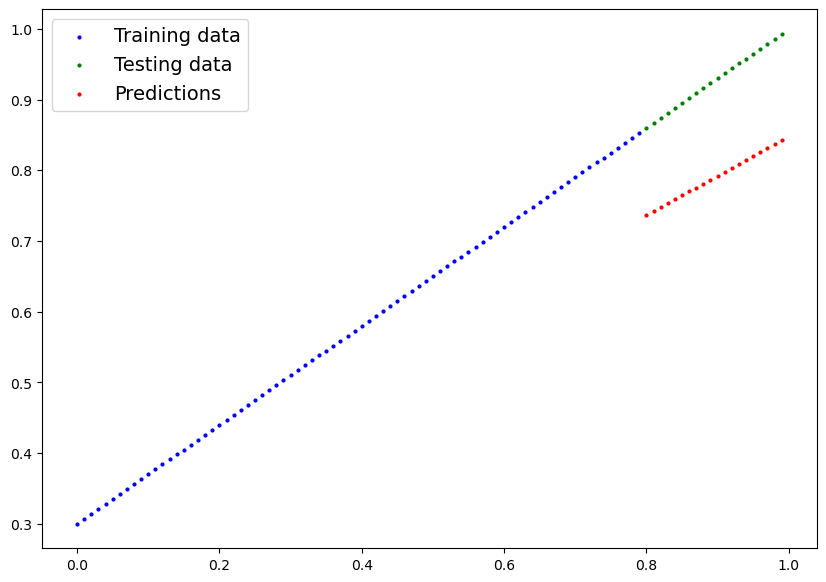

In [162]:
# Turn on evaluation mode
model_2.eval()

with torch.inference_mode():
    y_preds = model_2(X_test_regression)

plot_predictions(
                train_data = X_train_regression.cpu(),
                train_labels = y_train_regression.cpu(),
                test_data= X_test_regression.cpu(),
                test_labels= y_test_regression.cpu(),
                predictions= y_preds.cpu()
)

## 6. Missing piece : Non linearity 

" What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?"  

Or in machine learning terms, an infinite (but reality it is finite)  of linear and non linear functions?  



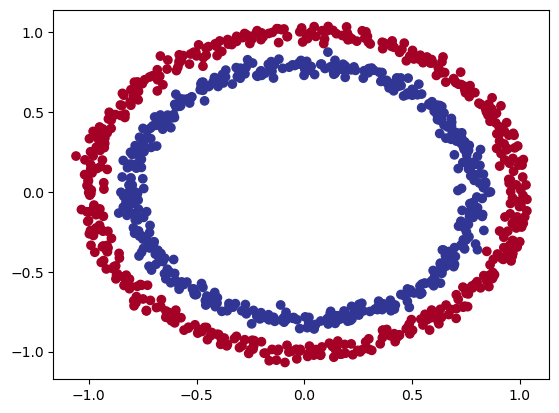

In [163]:
### 6.1 Recreating non-linear data (red and blue circles)
import sklearn
from sklearn.datasets import make_circles

## Make the 1000 samples
n_samples = 1000 

#Create circles 
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42

)

plt.scatter(X[:,0],X[:,1], c=y , cmap=plt.cm.RdYlBu)




In [164]:
# convert the data to tensors and then to train and test spilts
import torch 
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split the train test split 

X_train , X_test, y_train , y_test = train_test_split(
                                                      X,
                                                      y,
                                                      test_size=0.2,
                                                      random_state=42
)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non linearity

* Linear = straight linear
* Nonlinear = non-straight lines

In [165]:
# Build a model with non-linear activation functions

from torch import nn 
class CirclemodelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10,out_features=1)

        self.relu = nn.ReLU() #relu is a non-linear activation function

    def forward(self,x):
        # where should we put our non-linear activation functions?
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    

model_3 = CirclemodelV2().to(device)
model_3


CirclemodelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [166]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),
                            lr=0.1)

### 6.3 training the model with non linearity

In [167]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train , y_train = X_train.to(device), y_train.to(device)
X_test , y_test = X_test.to(device), y_test.to(device)

epochs = 1000

for epoch in range(epochs):
    model_3.train()

    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits,y_train) # BCEWithLogitsLoss (takes in logits as first input)

    acc = accuracy_fn(y_true=y_train,y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # testing

    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,y_test)
        testacc = accuracy_fn(y_true=y_test,y_pred=test_pred)


    if epoch % 100 == 0:
        print(f"Epcoh: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")







Epcoh: 0 | Loss: 0.6929, Acc: 50.00% | Test Loss: 0.6932 | Test Acc: 46.00%
Epcoh: 100 | Loss: 0.6912, Acc: 52.88% | Test Loss: 0.6910 | Test Acc: 46.00%
Epcoh: 200 | Loss: 0.6898, Acc: 53.37% | Test Loss: 0.6894 | Test Acc: 46.00%
Epcoh: 300 | Loss: 0.6879, Acc: 53.00% | Test Loss: 0.6872 | Test Acc: 46.00%
Epcoh: 400 | Loss: 0.6852, Acc: 52.75% | Test Loss: 0.6841 | Test Acc: 46.00%
Epcoh: 500 | Loss: 0.6810, Acc: 52.75% | Test Loss: 0.6794 | Test Acc: 46.00%
Epcoh: 600 | Loss: 0.6751, Acc: 54.50% | Test Loss: 0.6729 | Test Acc: 46.00%
Epcoh: 700 | Loss: 0.6666, Acc: 58.38% | Test Loss: 0.6632 | Test Acc: 46.00%
Epcoh: 800 | Loss: 0.6516, Acc: 64.00% | Test Loss: 0.6476 | Test Acc: 46.00%
Epcoh: 900 | Loss: 0.6236, Acc: 74.00% | Test Loss: 0.6215 | Test Acc: 46.00%


### 6.4 evaluating the model trained with non linear functions

In [168]:
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds[:10],y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

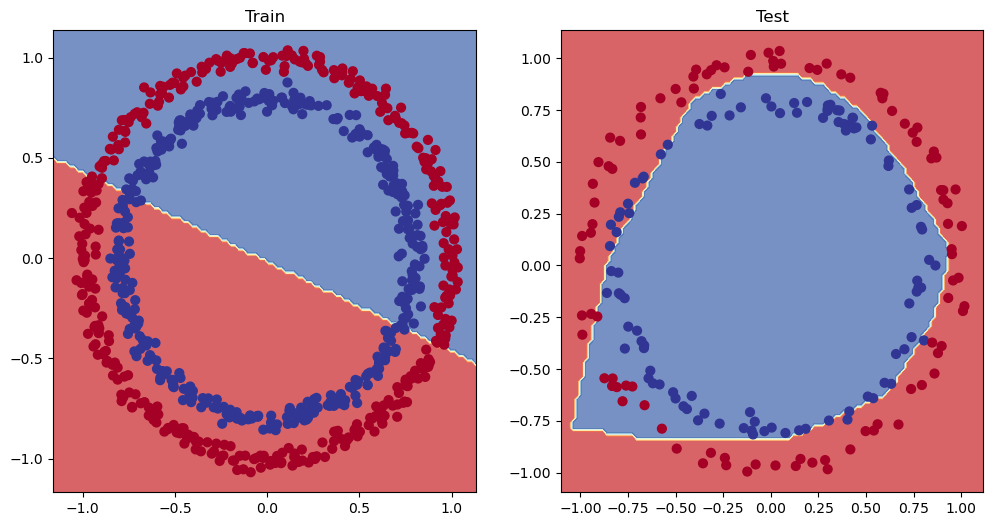

In [169]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test)

## 7. Replicating non-linear activation functions.

Neural networks, rather than us telling the model what to learn we give it the tools to discover patterns in data and it tries to figure out the patterns on its own.  

and these tools are linear and non linear fucntions

In [170]:
# create a tensor 

A = torch.arange(-10,10,1,dtype = torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

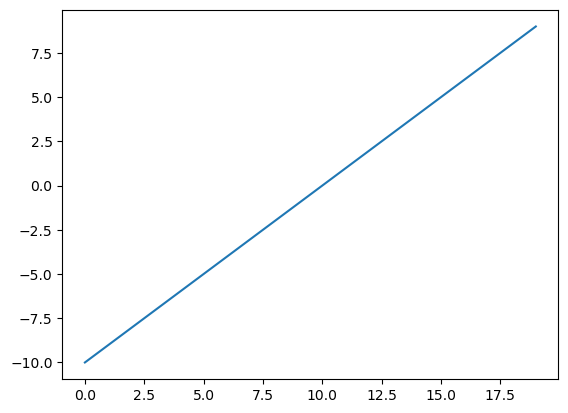

In [171]:
plt.plot(A)

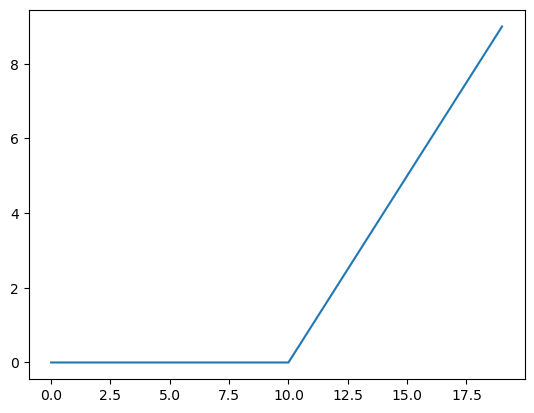

In [172]:
plt.plot(torch.relu(A))

In [173]:
def relu(x):
    return torch.maximum(torch.tensor(0),x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

In [174]:
# Now lets do the same for sigmoid

def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

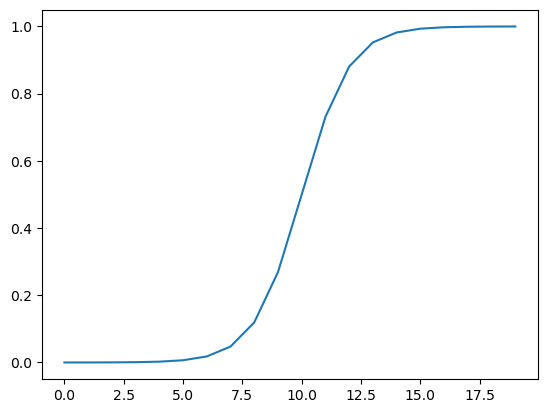

In [175]:
plt.plot(torch.sigmoid(A))

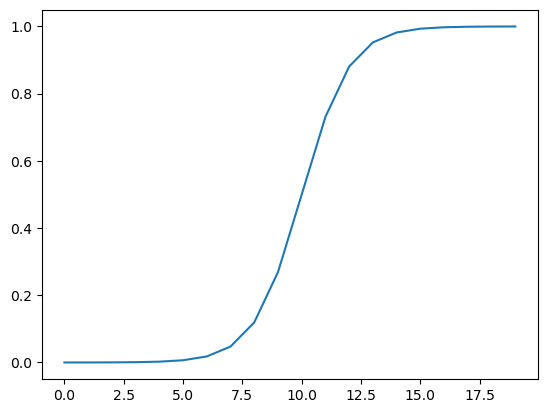

In [176]:
plt.plot(sigmoid(A))

## 8. Putting all together with multi-class classification problem

* Binary Classification = one thing or another(cat vs dog, spam vs not spam fraud or not fraud)  
* Multi-class classification = more than one thing or another (cat vs dog vs chicken)

### 8.1 Create a toy multi-class dataset


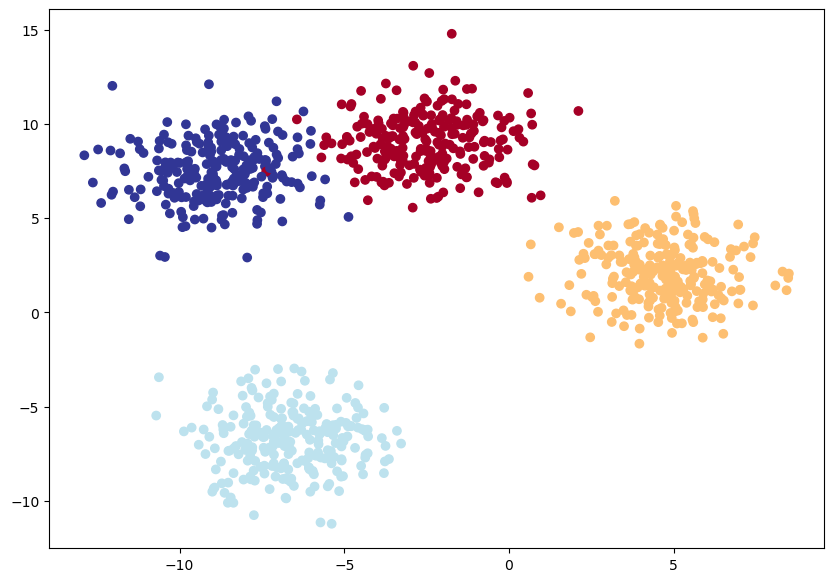

In [177]:
import torch 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split 
from torch import nn


# Set the hyperparameter

NUM_CLASSES = 4 
NUM_FEATURES = 2
RANDOM_SEED = 42


# Create the multi class data

X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5,
                            random_state = RANDOM_SEED)


# Turn the data into the tensors

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)


#Split train test split 
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.20,
                                                                        random_state=RANDOM_SEED)

# plot the data (Visualize)
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)                                                                    


### 8.2 Building a multi-class classification model in pytorch

In [178]:
# create the device agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [179]:
# Build a multi class classification model
class BlobModel(nn.Module):
    def __init__(self,input_features,output_features,hidden_units=8):
        """ Initialize multi-class classification model.
        
        Args:
            input_features (int) = Number of the input features to the model
            ouput_features (int) = Number of output features (No.of output classes)
            hidden_units (int) = Number of hidden units between layers, default 8

        Returns 
        
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_features)
        )

    def forward(self,x):
        return self.linear_layer_stack(x)
    
# create the model

model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [180]:
X_blob_train.shape 

torch.Size([800, 2])

In [181]:
torch.unique(y_blob_train)

tensor([0., 1., 2., 3.])

### 8.3 create the loss function and an optimizer for multi-class classification model

In [182]:
#Create a loss fucntion for multiclass classification

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

### 8.4 Getting prediction probabailities for a multi class Pytorch model  

In order to evaluate and train and test our model, we need to convert our models output (logits) to prediction probabilities and then to prediction labels.  

Logits -> pred probs -> pred labels  

In [183]:
next(model_4.parameters()).device

device(type='cuda', index=0)

In [184]:
# Lets get some raw outputs of our model (logits)
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test.to(device))

y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]], device='cuda:0')

In [185]:
y_blob_test[:10]

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.])

In [186]:
# Converts our models logits output to predcition probabilities
y_pred_probs = torch.softmax(y_logits,dim=1)

print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]], device='cuda:0')
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]], device='cuda:0')


In [187]:
torch.sum(y_pred_probs[0])

tensor(1., device='cuda:0')

In [188]:
torch.max(y_pred_probs[0])

tensor(0.3244, device='cuda:0')

In [189]:
# Convert our models prediction probabailities to prediction labels
y_preds = torch.argmax(y_pred_probs,dim=1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1], device='cuda:0')

In [190]:
y_blob_test

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0., 0., 1., 0., 0., 0., 3., 3., 2.,
        3., 3., 3., 0., 1., 2., 2., 2., 3., 0., 1., 0., 3., 1., 1., 3., 1., 2.,
        1., 3., 0., 2., 0., 3., 3., 2., 0., 3., 1., 1., 0., 3., 1., 0., 1., 1.,
        3., 2., 1., 1., 3., 2., 2., 0., 3., 2., 2., 0., 0., 3., 3., 0., 0., 3.,
        3., 3., 2., 3., 3., 3., 3., 1., 0., 2., 3., 2., 3., 3., 2., 3., 3., 2.,
        3., 3., 1., 3., 3., 3., 1., 0., 3., 2., 0., 0., 3., 0., 2., 3., 1., 0.,
        3., 2., 1., 1., 0., 2., 2., 3., 0., 0., 1., 2., 2., 3., 0., 1., 2., 0.,
        0., 0., 2., 3., 1., 2., 3., 2., 0., 3., 0., 0., 1., 1., 1., 0., 2., 2.,
        2., 2., 0., 3., 3., 2., 2., 1., 3., 2., 0., 0., 3., 3., 2., 1., 2., 0.,
        3., 2., 0., 3., 2., 0., 2., 2., 2., 0., 3., 1., 1., 1., 1., 1., 3., 1.,
        0., 2., 2., 1., 2., 2., 0., 1., 2., 2., 0., 0., 1., 3., 2., 0., 3., 1.,
        2., 1.])

### 8.5 Creating a training loop and testing loop for a multi class Pytorch model

In [191]:
# Fit the multiclass model to the data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

# put the data to the device

X_blob_train ,y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test , y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# Convert labels to long
y_blob_train = y_blob_train.long()
y_blob_test = y_blob_test.long()


for epoch in range(epochs):
    model_4.train()

    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

    loss = loss_fn(y_logits,y_blob_train)

    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ## testing 

    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_blob_test)
        test_preds = torch.softmax(test_logits,dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits,y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test,
                               y_pred=test_preds)
        
    if epoch % 10 ==0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.1588 | Acc: 40.38% | Test Loss: 1.0755, Test acc: 48.00%
Epoch: 10 | Loss: 0.6448 | Acc: 96.75% | Test Loss: 0.6607, Test acc: 97.50%
Epoch: 20 | Loss: 0.4254 | Acc: 98.50% | Test Loss: 0.4307, Test acc: 100.00%
Epoch: 30 | Loss: 0.2529 | Acc: 99.12% | Test Loss: 0.2451, Test acc: 99.50%
Epoch: 40 | Loss: 0.1123 | Acc: 99.25% | Test Loss: 0.1023, Test acc: 99.50%
Epoch: 50 | Loss: 0.0663 | Acc: 99.25% | Test Loss: 0.0585, Test acc: 99.50%
Epoch: 60 | Loss: 0.0507 | Acc: 99.25% | Test Loss: 0.0429, Test acc: 99.50%
Epoch: 70 | Loss: 0.0430 | Acc: 99.25% | Test Loss: 0.0349, Test acc: 99.50%
Epoch: 80 | Loss: 0.0384 | Acc: 99.25% | Test Loss: 0.0299, Test acc: 99.50%
Epoch: 90 | Loss: 0.0352 | Acc: 99.25% | Test Loss: 0.0266, Test acc: 99.50%


### 8.6 Making and evaluate predictions with Pytorch multiclass model  

In [192]:
# make prediction 
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# view the first 10 prediction
y_logits[:10]


tensor([[-0.6249,  5.9860, -7.6323, -8.4470],
        [-2.1738, -6.3750, -3.7202,  3.1203],
        [-3.4102, -3.8958,  3.1567, -2.6119],
        [-1.1505,  4.1962, -3.8472, -4.8820],
        [ 3.7548, -1.3391, -9.1422, -6.9466],
        [-2.8211, -7.5767, -4.2944,  3.7944],
        [-3.0306, -3.3328,  2.7955, -2.1374],
        [ 3.3761, -4.0375, -6.8987, -3.5503],
        [-4.3620, -4.9904,  3.8123, -3.3814],
        [ 3.5012, -3.0281, -7.5401, -4.7064]], device='cuda:0')

In [193]:
# logits -> prediction probabailities
y_pred_probs = torch.softmax(y_logits,dim=1)

In [194]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1], device='cuda:0')

In [195]:
y_pred_probs = torch.softmax(y_logits,dim=1).argmax(dim=1)

y_pred_probs

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 0, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1], device='cuda:0')

In [196]:
torch.eq(y_pred_probs,y_blob_test)

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True, 

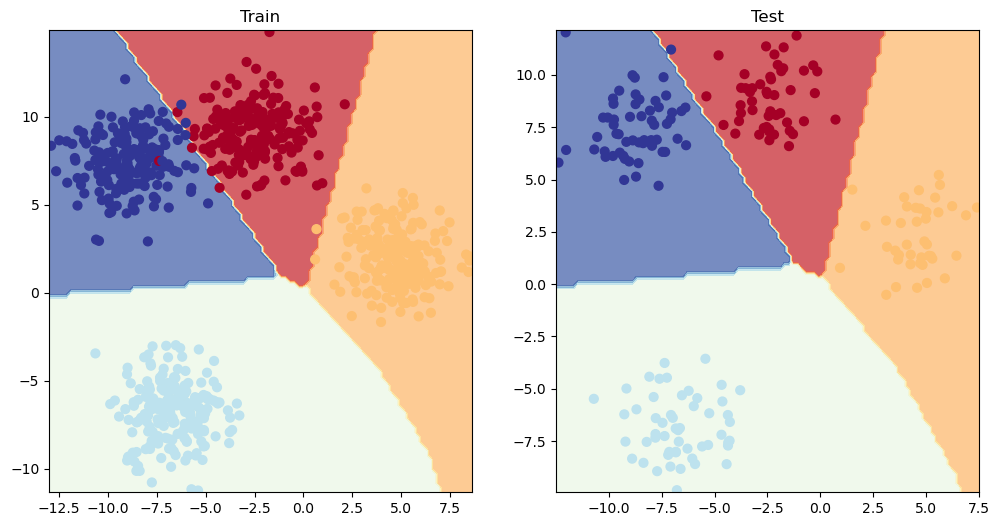

In [197]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4,X_blob_train,y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4,X_blob_test,y_blob_test)

## 9. A few more classification metrics... (to evaluate our classification model)  

* Accuracy - out of 100 samples, how many does out model get right?
* precision
* recall 
* F1 score 
* Confusion matrix
* Classification report 



In [206]:
import torchmetrics
from torchmetrics import Accuracy

torchmetric_accuracy = Accuracy(task="multiclass",num_classes=4).to(device)

torchmetric_accuracy(y_preds,y_blob_test)

tensor(0.3550, device='cuda:0')